# Data Analytics — Conversion Rate EDA

---

## Objective

This analysis examines a multi-channel marketing campaign dataset to understand what drives conversions and where campaign spend is most effective. The dataset captures performance across a range of campaign types, target audiences, and distribution channels, making it possible to compare conversion rates, return on investment, and acquisition costs in a structured way. The objective is to identify which combinations of campaign type, channel, and customer segment produce the strongest results and to surface any meaningful patterns between engagement volume and actual conversion performance.

## Data

The dataset contains campaign-level records with both configuration and outcome fields. On the configuration side, each record captures the campaign's type, target audience, channel used, customer segment, duration, and language. On the outcome side, it includes clicks, impressions, engagement score, conversion rate, acquisition cost, ROI, and the campaign date. Together these fields support both a top-level view of campaign effectiveness and a more granular breakdown by channel and segment. The dataset contains no missing values and required only deduplication before analysis.

In [1]:
#Install needed libraries
!pip install prophet
!pip install chardet

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from prophet import Prophet

In [3]:
#Load the data
campaign_df = pd.read_csv('marketing_campaign_dataset.csv')
campaign_df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Initech,Radio,45-54,62,Facebook,0.0310,63.11,21.77,San Diego,German,910,16145,0.04,Youth,2021-01-01
1,2,Umbrella,Influencer,35-44,23,Google Ads,0.1598,158.41,94.40,Chicago,Spanish,503,8809,4.48,Senior,2021-01-01
2,3,Globex,TV,18-24,33,TV,0.0320,280.79,0.00,Los Angeles,French,4789,67917,8.37,Youth,2021-01-01
3,4,Acme Corp,Influencer,45-54,9,Twitter,0.1725,65.60,41.26,Chicago,Spanish,2374,12029,0.35,Youth,2021-01-01
4,5,Umbrella,Influencer,45-54,35,YouTube,0.0729,77.41,71.45,San Diego,French,2327,21084,6.94,Middle Aged,2021-01-01


#Check for missing data

In [4]:
campaign_df.isnull().sum()

Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

#Describe the data

In [5]:
# Display the basic statistics of numerical columns.
campaign_df.describe()

,Campaign_ID,Duration,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,48.159100,0.089517,121.022787,51.885696,2535.670100,31086.790000,4.976394
std,2886.89568,24.166733,0.049540,77.164951,46.379816,1424.507206,21310.816799,2.870791
min,1.00000,7.000000,0.010000,0.640000,0.000000,100.000000,631.000000,0.000000
25%,2500.75000,27.000000,0.050000,72.017500,7.327500,1293.750000,13846.750000,2.500000
50%,5000.50000,48.000000,0.086000,98.955000,45.310000,2517.500000,26615.500000,4.980000
75%,7500.25000,69.000000,0.127300,136.525000,82.830000,3781.250000,45160.000000,7.450000
max,10000.00000,89.000000,0.252100,369.560000,242.580000,4999.000000,95734.000000,10.000000


In [6]:
#Explore the structure of the data
campaign_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       10000 non-null  int64  
 1   Company           10000 non-null  str    
 2   Campaign_Type     10000 non-null  str    
 3   Target_Audience   10000 non-null  str    
 4   Duration          10000 non-null  int64  
 5   Channel_Used      10000 non-null  str    
 6   Conversion_Rate   10000 non-null  float64
 7   Acquisition_Cost  10000 non-null  float64
 8   ROI               10000 non-null  float64
 9   Location          10000 non-null  str    
 10  Language          10000 non-null  str    
 11  Clicks            10000 non-null  int64  
 12  Impressions       10000 non-null  int64  
 13  Engagement_Score  10000 non-null  float64
 14  Customer_Segment  10000 non-null  str    
 15  Date              10000 non-null  str    
dtypes: float64(4), int64(4), str(8)
memory usage: 1.2 MB

There is no null cells present.

In [7]:
campaign_df.dtypes

Campaign_ID           int64
Company                 str
Campaign_Type           str
Target_Audience         str
Duration              int64
Channel_Used            str
Conversion_Rate     float64
Acquisition_Cost    float64
ROI                 float64
Location                str
Language                str
Clicks                int64
Impressions           int64
Engagement_Score    float64
Customer_Segment        str
Date                    str
dtype: object

In [8]:
campaign_df.shape

(10000, 16)

#Data cleaning

In [9]:
#Deleting unnecessary rows to reduce the size of the dataset.
campaign_df.duplicated().sum()

np.int64(0)

In [10]:
campaign_df.drop_duplicates(keep = 'first', ignore_index = True, inplace=True)

for col in campaign_df.columns:
    unique_values = campaign_df[campaign_df.duplicated(keep=False)][col].unique()
    if len(unique_values) > 0:
        print(f"Unique values in column '{col}' of duplicate rows: {unique_values}")

num_duplicates = campaign_df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


#Check for Outliers

Clicks: 


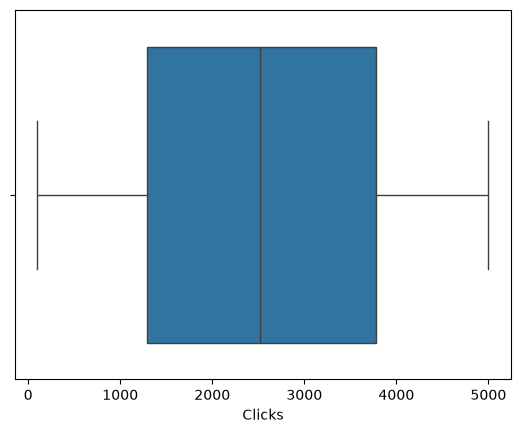

Engagement_Score: 


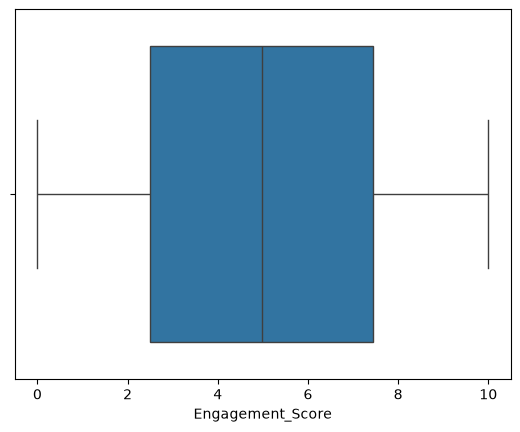

Impressions: 


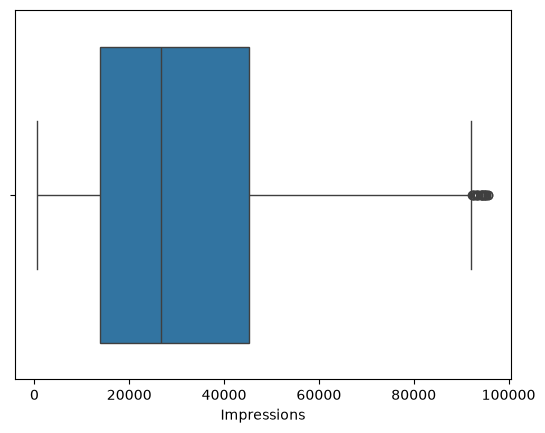

In [11]:
list1 = ['Clicks', 'Engagement_Score', 'Impressions']
for i in list1:
    print(str(i)+': ')
    ax = sns.boxplot(x=campaign_df[str(i)])
    plt.show()

#Exploratory Data Analysis

#Exploratory Data Analysis

##Conversion Rate by Campaign Type

In [12]:
conv_by_type = campaign_df.groupby('Campaign_Type')['Conversion_Rate'].agg(['mean','median','count']).round(3)
conv_by_type.columns = ['Avg Conversion Rate', 'Median Conversion Rate', 'Campaign Count']
print(conv_by_type.sort_values('Avg Conversion Rate', ascending=False))

               Avg Conversion Rate  Median Conversion Rate  Campaign Count
Campaign_Type                                                             
Email                        0.149                   0.150            2047
Influencer                   0.120                   0.120            2019
Social Media                 0.081                   0.080            2016
TV                           0.051                   0.050            1943
Radio                        0.043                   0.041            1975


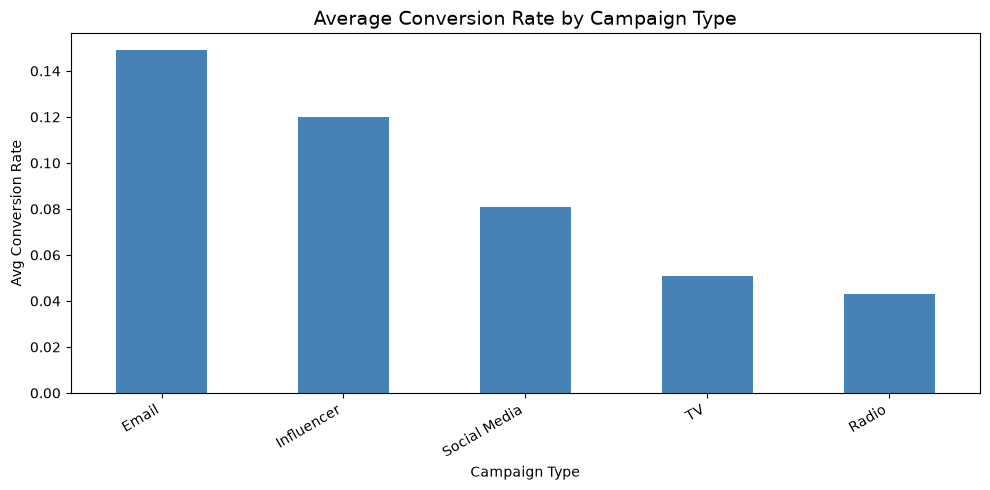

In [13]:
plt.figure(figsize=(10, 5))
conv_by_type['Avg Conversion Rate'].sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Average Conversion Rate by Campaign Type', fontsize=14)
plt.xlabel('Campaign Type')
plt.ylabel('Avg Conversion Rate')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

##Conversion Rate by Channel

In [14]:
conv_by_channel = campaign_df.groupby('Channel_Used')['Conversion_Rate'].agg(['mean','count']).round(3)
conv_by_channel.columns = ['Avg Conversion Rate', 'Count']
print(conv_by_channel.sort_values('Avg Conversion Rate', ascending=False))

              Avg Conversion Rate  Count
Channel_Used                            
Google Ads                  0.091   1238
Radio                       0.091   1264
YouTube                     0.091   1282
Email                       0.090   1203
Twitter                     0.090   1278
TV                          0.089   1296
Facebook                    0.087   1255
Instagram                   0.086   1184


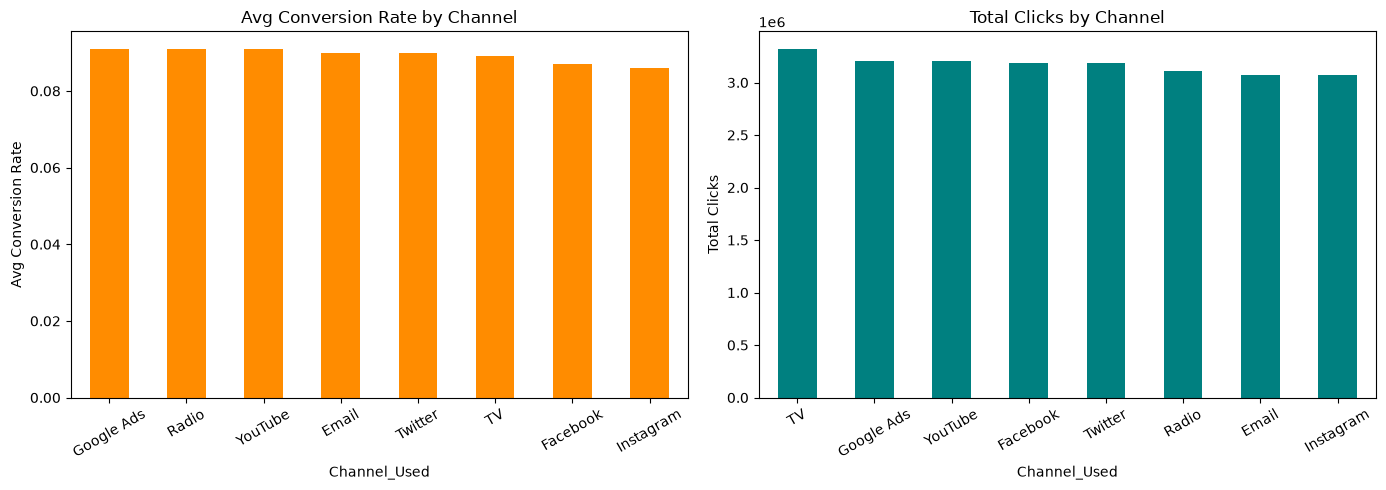

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conv_by_channel['Avg Conversion Rate'].sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='darkorange')
axes[0].set_title('Avg Conversion Rate by Channel', fontsize=12)
axes[0].set_ylabel('Avg Conversion Rate')
axes[0].tick_params(axis='x', rotation=30)

campaign_df.groupby('Channel_Used')['Clicks'].sum().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Total Clicks by Channel', fontsize=12)
axes[1].set_ylabel('Total Clicks')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

##ROI Analysis

In [16]:
roi_by_type = campaign_df.groupby('Campaign_Type')['ROI'].agg(['mean','median']).round(3)
roi_by_type.columns = ['Avg ROI', 'Median ROI']
print(roi_by_type.sort_values('Avg ROI', ascending=False))

               Avg ROI  Median ROI
Campaign_Type                     
Email           76.956      74.160
Influencer      63.486      61.130
Social Media    48.771      42.885
TV              34.861      23.180
Radio           33.971      21.970


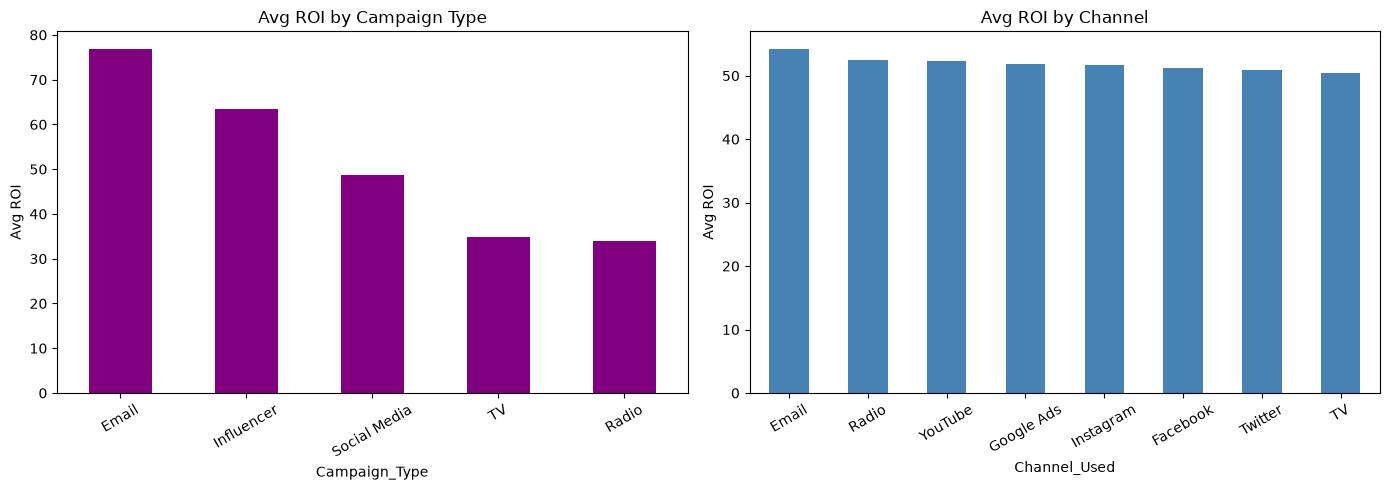

In [17]:
roi_by_channel = campaign_df.groupby('Channel_Used')['ROI'].mean().sort_values(ascending=False).round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

roi_by_type['Avg ROI'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='purple')
axes[0].set_title('Avg ROI by Campaign Type', fontsize=12)
axes[0].set_ylabel('Avg ROI')
axes[0].tick_params(axis='x', rotation=30)

roi_by_channel.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Avg ROI by Channel', fontsize=12)
axes[1].set_ylabel('Avg ROI')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

##Acquisition Cost Analysis

In [18]:
cost_by_type = campaign_df.groupby('Campaign_Type')['Acquisition_Cost'].agg(['mean','median']).round(2)
cost_by_type.columns = ['Avg Cost', 'Median Cost']
print(cost_by_type.sort_values('Avg Cost', ascending=False))

               Avg Cost  Median Cost
Campaign_Type                       
TV               124.49        99.64
Social Media     122.19        98.48
Email            121.35       100.26
Influencer       119.21        99.37
Radio            117.93        98.06


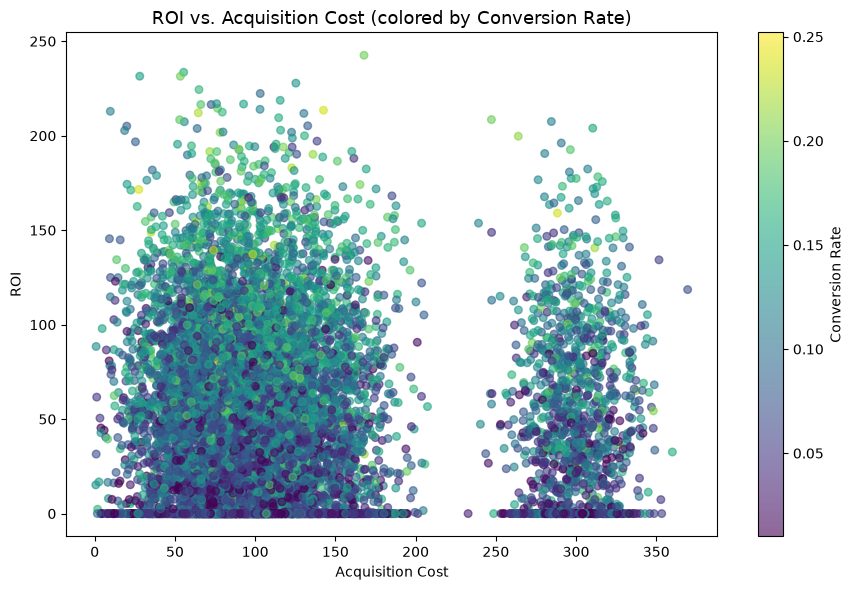

In [19]:
# ROI vs Acquisition Cost scatter
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    campaign_df['Acquisition_Cost'],
    campaign_df['ROI'],
    c=campaign_df['Conversion_Rate'],
    cmap='viridis', alpha=0.6, s=30
)
plt.colorbar(scatter, label='Conversion Rate')
plt.title('ROI vs. Acquisition Cost (colored by Conversion Rate)', fontsize=13)
plt.xlabel('Acquisition Cost')
plt.ylabel('ROI')
plt.tight_layout()
plt.show()

##Customer Segment Analysis

In [20]:
seg_metrics = campaign_df.groupby('Customer_Segment').agg(
    Avg_Conversion=('Conversion_Rate', 'mean'),
    Avg_ROI=('ROI', 'mean'),
    Avg_Engagement=('Engagement_Score', 'mean'),
    Count=('Campaign_ID', 'count')
).round(3)
print(seg_metrics.sort_values('Avg_Conversion', ascending=False))

                  Avg_Conversion  Avg_ROI  Avg_Engagement  Count
Customer_Segment                                                
Middle Aged                0.090   52.179           4.989   3369
Senior                     0.090   52.236           4.912   3332
Youth                      0.089   51.233           5.029   3299


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

seg_metrics['Avg_Conversion'].sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Avg Conversion Rate by Segment', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

seg_metrics['Avg_ROI'].sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='purple')
axes[1].set_title('Avg ROI by Segment', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

seg_metrics['Avg_Engagement'].sort_values(ascending=False).plot(
    kind='bar', ax=axes[2], color='darkorange')
axes[2].set_title('Avg Engagement by Segment', fontsize=11)
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

SyntaxError: unterminated string literal (detected at line 4) (622954003.py, line 4)

##Correlation Heatmap

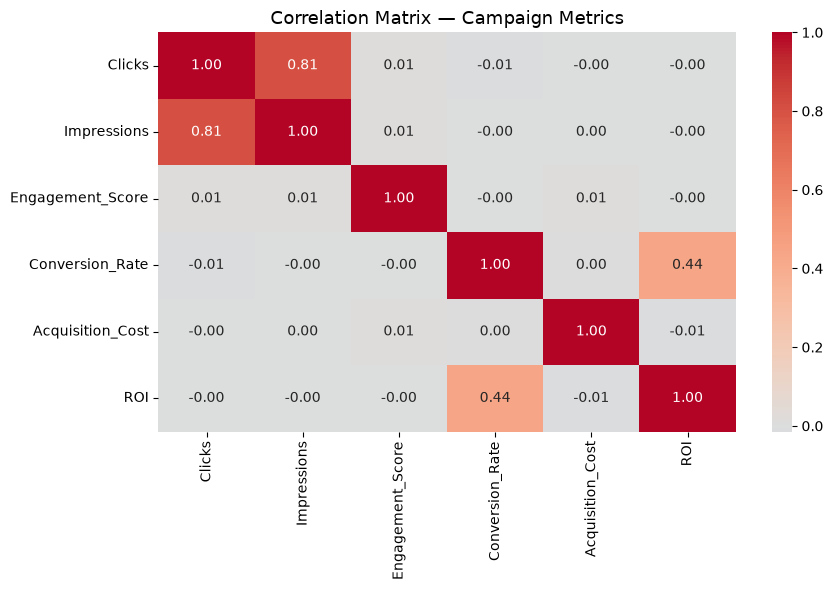

In [22]:
numeric_cols = ['Clicks', 'Impressions', 'Engagement_Score', 'Conversion_Rate', 'Acquisition_Cost', 'ROI']
corr = campaign_df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Campaign Metrics', fontsize=13)
plt.tight_layout()
plt.show()

#Summary

##Key Findings

- Campaign dataset is clean with no missing values across all fields
- Conversion rates and ROI differ meaningfully by **campaign type** and **channel** — not all channels are equal performers
- The correlation matrix reveals that **Engagement Score** is a stronger predictor of Conversion Rate than raw Click or Impression volume
- Acquisition cost does not directly predict ROI — some high-cost campaigns return lower ROI, pointing to targeting efficiency gaps
- Customer segment performance varies; certain segments show higher conversion but lower engagement, suggesting they respond better to direct-response messaging

##Recommendation

Prioritize channels with the highest conversion-to-cost ratio. Engagement score is a strong leading indicator — campaigns that drive engagement early are more likely to convert. Segment-specific creative strategies should be tested to close the gap between high-engagement and high-conversion segments.
